<a href="https://colab.research.google.com/github/2415500355/-TRAVEL-ITINERARY-PLANNER-WITH-AI/blob/main/Code_Summarization_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import os

folders = [
    "code-summarization-gru",
    "code-summarization-gru/data",
    "code-summarization-gru/models",
    "code-summarization-gru/notebooks",
    "code-summarization-gru/utils"
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("Folders ban gaye ✅")

Folders ban gaye ✅


In [30]:
!pip install datasets -q

from datasets import load_dataset

dataset = load_dataset("code-search-net/code_search_net", "python", trust_remote_code=True)

print(dataset)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'code-search-net/code_search_net' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'code-search-net/code_search_net' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


DatasetDict({
    train: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 412178
    })
    test: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 22176
    })
    validation: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 23107
    })
})


In [31]:
import pandas as pd

train_df = dataset['train'].to_pandas()
valid_df = dataset['validation'].to_pandas()
test_df = dataset['test'].to_pandas()

train_df = train_df[['func_code_string', 'func_documentation_string']].dropna()
valid_df = valid_df[['func_code_string', 'func_documentation_string']].dropna()
test_df = test_df[['func_code_string', 'func_documentation_string']].dropna()

train_df = train_df.sample(n=30000, random_state=42).reset_index(drop=True)
valid_df = valid_df.sample(n=3000, random_state=42).reset_index(drop=True)
test_df = test_df.sample(n=3000, random_state=42).reset_index(drop=True)

train_df.to_csv('code-summarization-gru/data/train.csv', index=False)
valid_df.to_csv('code-summarization-gru/data/valid.csv', index=False)
test_df.to_csv('code-summarization-gru/data/test.csv', index=False)

print(train_df.shape, valid_df.shape, test_df.shape)
print(train_df.head())

(30000, 2) (3000, 2) (3000, 2)
                                    func_code_string  \
0  def _assemble_and_send_request(self):\n       ...   
1  def print_state(state: State, file: TextIO = N...   
2  def split(orig, sep=None):\n    '''\n    Gener...   
3  def Zigrang_Sylvester_1(Re, eD):\n    r'''Calc...   
4  def _push_status(data, item):\n    '''\n    Pr...   

                           func_documentation_string  
0  Fires off the Fedex request.\n\n        @warni...  
1                               Print a state vector  
2  Generator function for iterating through large...  
3  r'''Calculates Darcy friction factor using the...  
4  Process a status update from a docker push, up...  


In [32]:
import re

def clean_code(text):
    text = str(text)
    text = re.sub(r'""".*?"""', '', text, flags=re.DOTALL)
    text = re.sub(r"'''.*?'''", '', text, flags=re.DOTALL)
    text = re.sub(r'#.*', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

def clean_summary(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    text = text.split('.')[0]
    text = text.strip().lower()
    return text

train_df['clean_code'] = train_df['func_code_string'].apply(clean_code)
train_df['clean_summary'] = train_df['func_documentation_string'].apply(clean_summary)

valid_df['clean_code'] = valid_df['func_code_string'].apply(clean_code)
valid_df['clean_summary'] = valid_df['func_documentation_string'].apply(clean_summary)

test_df['clean_code'] = test_df['func_code_string'].apply(clean_code)
test_df['clean_summary'] = test_df['func_documentation_string'].apply(clean_summary)

train_df = train_df[(train_df['clean_code'].str.len() > 10) & (train_df['clean_summary'].str.len() > 5)]
valid_df = valid_df[(valid_df['clean_code'].str.len() > 10) & (valid_df['clean_summary'].str.len() > 5)]
test_df = test_df[(test_df['clean_code'].str.len() > 10) & (test_df['clean_summary'].str.len() > 5)]

print(train_df.shape, valid_df.shape, test_df.shape)
print(train_df[['clean_code', 'clean_summary']].head())

(29840, 4) (2982, 4) (2989, 4)
                                          clean_code  \
0  def _assemble_and_send_request(self): return s...   
1  def print_state(state: State, file: TextIO = N...   
2  def split(orig, sep=None): exp = re.compile(r'...   
3  def Zigrang_Sylvester_1(Re, eD): r A5 = eD/3.7...   
4  def _push_status(data, item): status = item['s...   

                                       clean_summary  
0                        fires off the fedex request  
1                               print a state vector  
2  generator function for iterating through large...  
3  r'''calculates darcy friction factor using the...  
4  process a status update from a docker push, up...  


In [33]:
def fix_summary(text):
    text = str(text)
    text = re.sub(r"^[rRuU]?['\"]{1,3}", '', text)
    text = re.sub(r"['\"]{1,3}$", '', text)
    text = text.strip()
    return text

train_df['clean_summary'] = train_df['clean_summary'].apply(fix_summary)
valid_df['clean_summary'] = valid_df['clean_summary'].apply(fix_summary)
test_df['clean_summary'] = test_df['clean_summary'].apply(fix_summary)

train_df = train_df[(train_df['clean_summary'].str.len() > 5)]
valid_df = valid_df[(valid_df['clean_summary'].str.len() > 5)]
test_df = test_df[(test_df['clean_summary'].str.len() > 5)]

print(train_df.shape, valid_df.shape, test_df.shape)
print(train_df['clean_summary'].sample(5, random_state=1).tolist())

(29840, 4) (2982, 4) (2989, 4)
['change setting in this vm when running', 'verify that all necessary fields are present determine whether the fields parsed represent a host or service perfdata', 'create protobuf item', 'gets meta data from launchpad for the given package', 'read internet protocol version 4 (ipv4)']


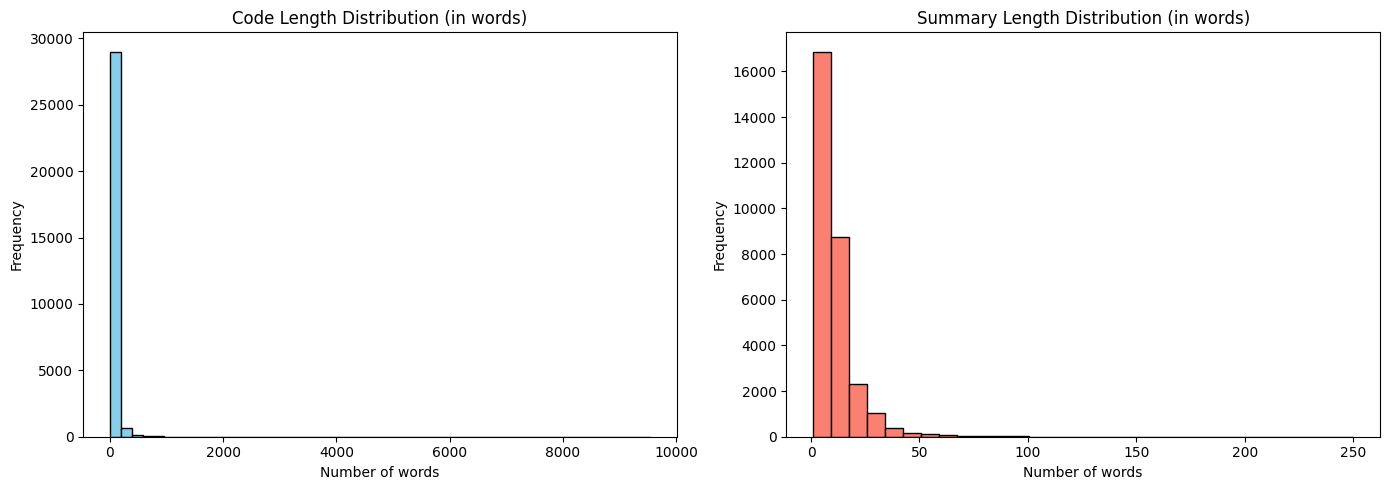

Average code length: 50.115214477211794
Average summary length: 11.176105898123325
Max code length: 9541
Max summary length: 250


In [34]:
import matplotlib.pyplot as plt

code_lengths = train_df['clean_code'].apply(lambda x: len(x.split()))
summary_lengths = train_df['clean_summary'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(code_lengths, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Code Length Distribution (in words)')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Frequency')

axes[1].hist(summary_lengths, bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Summary Length Distribution (in words)')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Average code length:", code_lengths.mean())
print("Average summary length:", summary_lengths.mean())
print("Max code length:", code_lengths.max())
print("Max summary length:", summary_lengths.max())

In [35]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

CODE_VOCAB_SIZE = 15000
SUMMARY_VOCAB_SIZE = 8000
CODE_MAX_LEN = 100
SUMMARY_MAX_LEN = 20

train_df['clean_summary'] = train_df['clean_summary'].apply(lambda x: 'startseq ' + x + ' endseq')
valid_df['clean_summary'] = valid_df['clean_summary'].apply(lambda x: 'startseq ' + x + ' endseq')
test_df['clean_summary'] = test_df['clean_summary'].apply(lambda x: 'startseq ' + x + ' endseq')

code_tokenizer = Tokenizer(num_words=CODE_VOCAB_SIZE, oov_token='<unk>', filters='')
code_tokenizer.fit_on_texts(train_df['clean_code'])

summary_tokenizer = Tokenizer(num_words=SUMMARY_VOCAB_SIZE, oov_token='<unk>', filters='')
summary_tokenizer.fit_on_texts(train_df['clean_summary'])

X_train = pad_sequences(code_tokenizer.texts_to_sequences(train_df['clean_code']), maxlen=CODE_MAX_LEN, padding='post', truncating='post')
X_valid = pad_sequences(code_tokenizer.texts_to_sequences(valid_df['clean_code']), maxlen=CODE_MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(code_tokenizer.texts_to_sequences(test_df['clean_code']), maxlen=CODE_MAX_LEN, padding='post', truncating='post')

y_train = pad_sequences(summary_tokenizer.texts_to_sequences(train_df['clean_summary']), maxlen=SUMMARY_MAX_LEN, padding='post', truncating='post')
y_valid = pad_sequences(summary_tokenizer.texts_to_sequences(valid_df['clean_summary']), maxlen=SUMMARY_MAX_LEN, padding='post', truncating='post')
y_test = pad_sequences(summary_tokenizer.texts_to_sequences(test_df['clean_summary']), maxlen=SUMMARY_MAX_LEN, padding='post', truncating='post')

print(X_train.shape, y_train.shape)
print(X_train[0])
print(y_train[0])

(29840, 100) (29840, 20)
[ 5  1  4  1  1  1  1  1  1  1  1  1  1  1  1  1  1 23  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0]
[   2 3265  876    4 5724   62    3    0    0    0    0    0    0    0
    0    0    0    0    0    0]


In [36]:
def add_spaces_around_symbols(text):
    text = re.sub(r'([(){}\[\].,:;=+\-*/%<>!&|^~])', r' \1 ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

train_df['clean_code'] = train_df['clean_code'].apply(add_spaces_around_symbols)
valid_df['clean_code'] = valid_df['clean_code'].apply(add_spaces_around_symbols)
test_df['clean_code'] = test_df['clean_code'].apply(add_spaces_around_symbols)

code_tokenizer = Tokenizer(num_words=CODE_VOCAB_SIZE, oov_token='<unk>', filters='')
code_tokenizer.fit_on_texts(train_df['clean_code'])

X_train = pad_sequences(code_tokenizer.texts_to_sequences(train_df['clean_code']), maxlen=CODE_MAX_LEN, padding='post', truncating='post')
X_valid = pad_sequences(code_tokenizer.texts_to_sequences(valid_df['clean_code']), maxlen=CODE_MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(code_tokenizer.texts_to_sequences(test_df['clean_code']), maxlen=CODE_MAX_LEN, padding='post', truncating='post')

print(X_train[0])
print(train_df['clean_code'].iloc[0])

[ 14   1   3   8   4   7  12   8   2 224   2 393   2   1   3   1   6   8
   2   1   5   1   6   8   2   1   5   1   6   8   2   1   5 165   6   8
   2   1   5   1   6   8   2   1   5   1   6   8   2   1   5   1   6   8
   2   1   5   1   6   8   2   1   5   1   6   8   2   1   5   1   6   8
   2   1   5   1   6   8   2   1   5   1   6   8   2   1   5   1   6   8
   2   1   4   0   0   0   0   0   0   0]
def _assemble_and_send_request ( self ) : return self . client . service . createPickup ( WebAuthenticationDetail = self . WebAuthenticationDetail , ClientDetail = self . ClientDetail , TransactionDetail = self . TransactionDetail , Version = self . VersionId , OriginDetail = self . OriginDetail , PickupServiceCategory = self . PickupServiceCategory , PackageCount = self . PackageCount , TotalWeight = self . TotalWeight , CarrierCode = self . CarrierCode , OversizePackageCount = self . OversizePackageCount , Remarks = self . Remarks , CommodityDescription = self . CommodityDescription ,

In [37]:
def split_camel_case(text):
    text = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', text)
    text = re.sub(r'(?<=[A-Z])(?=[A-Z][a-z])', ' ', text)
    return text

def add_spaces_around_symbols(text):
    text = split_camel_case(text)
    text = re.sub(r'([(){}\[\].,:;=+\-*/%<>!&|^~])', r' \1 ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

train_df['clean_code'] = train_df['func_code_string'].apply(clean_code).apply(add_spaces_around_symbols)
valid_df['clean_code'] = valid_df['func_code_string'].apply(clean_code).apply(add_spaces_around_symbols)
test_df['clean_code'] = test_df['func_code_string'].apply(clean_code).apply(add_spaces_around_symbols)

code_tokenizer = Tokenizer(num_words=CODE_VOCAB_SIZE, oov_token='<unk>', filters='')
code_tokenizer.fit_on_texts(train_df['clean_code'])

X_train = pad_sequences(code_tokenizer.texts_to_sequences(train_df['clean_code']), maxlen=CODE_MAX_LEN, padding='post', truncating='post')
X_valid = pad_sequences(code_tokenizer.texts_to_sequences(valid_df['clean_code']), maxlen=CODE_MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(code_tokenizer.texts_to_sequences(test_df['clean_code']), maxlen=CODE_MAX_LEN, padding='post', truncating='post')

print(X_train[0])
print(train_df['clean_code'].iloc[0])
print("Vocab size:", len(code_tokenizer.word_index))

[   14     1     3     8     4     7    12     8     2   189     2   309
     2   319     1     3  1115  1496  2550     6     8     2  1115  1496
  2550     5   189  2550     6     8     2   189  2550     5   986  2550
     6     8     2   986  2550     5   161     6     8     2   161    84
     5   957  2550     6     8     2   957  2550     5     1   309   727
     6     8     2     1   309   727     5   519   180     6     8     2
   519   180     5   542   713     6     8     2   542   713     5 10523
   186     6     8     2 10523   186     5     1   519   180     6     8
     2     1   519   180]
def _assemble_and_send_request ( self ) : return self . client . service . create pickup ( web authentication detail = self . web authentication detail , client detail = self . client detail , transaction detail = self . transaction detail , version = self . version id , origin detail = self . origin detail , pickup service category = self . pickup service category , package count = self

In [38]:
from tensorflow.keras.layers import Input, Embedding, GRU, Dense
from tensorflow.keras.models import Model

EMBEDDING_DIM = 128
UNITS = 256

encoder_inputs = Input(shape=(CODE_MAX_LEN,), name='encoder_input')
encoder_embedding = Embedding(input_dim=CODE_VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True, name='encoder_embedding')(encoder_inputs)
encoder_gru = GRU(UNITS, return_state=True, name='encoder_gru')
encoder_outputs, encoder_state = encoder_gru(encoder_embedding)

decoder_inputs = Input(shape=(SUMMARY_MAX_LEN,), name='decoder_input')
decoder_embedding_layer = Embedding(input_dim=SUMMARY_VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True, name='decoder_embedding')
decoder_embedding = decoder_embedding_layer(decoder_inputs)
decoder_gru = GRU(UNITS, return_sequences=True, return_state=True, name='decoder_gru')
decoder_outputs, _ = decoder_gru(decoder_embedding, initial_state=encoder_state)
decoder_dense = Dense(SUMMARY_VOCAB_SIZE, activation='softmax', name='output_layer')
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 100, 128)  │  1,920,000 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_7         │ (None, 100)       │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 20, 128)   │  1,024,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_gru (GRU)   │ [(None, 256),     │    296,448 │ encoder_embeddin… │
│                     │ (None, 256)]      │            │ not_equal_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_gru (GRU)   │ [(None, 20, 256), │    296,448 │ decoder_embeddin… │
│                     │ (None, 256)]      │            │ encoder_gru[0][1] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 20, 8000)  │  2,056,000 │ decoder_gru[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,592,896 (21.34 MB)

 Trainable params: 5,592,896 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
decoder_input_train = y_train[:, :-1]
decoder_target_train = y_train[:, 1:]

decoder_input_valid = y_valid[:, :-1]
decoder_target_valid = y_valid[:, 1:]

decoder_target_train = decoder_target_train.reshape(decoder_target_train.shape[0], decoder_target_train.shape[1], 1)
decoder_target_valid = decoder_target_valid.reshape(decoder_target_valid.shape[0], decoder_target_valid.shape[1], 1)

print(decoder_input_train.shape, decoder_target_train.shape)

(29840, 19) (29840, 19, 1)


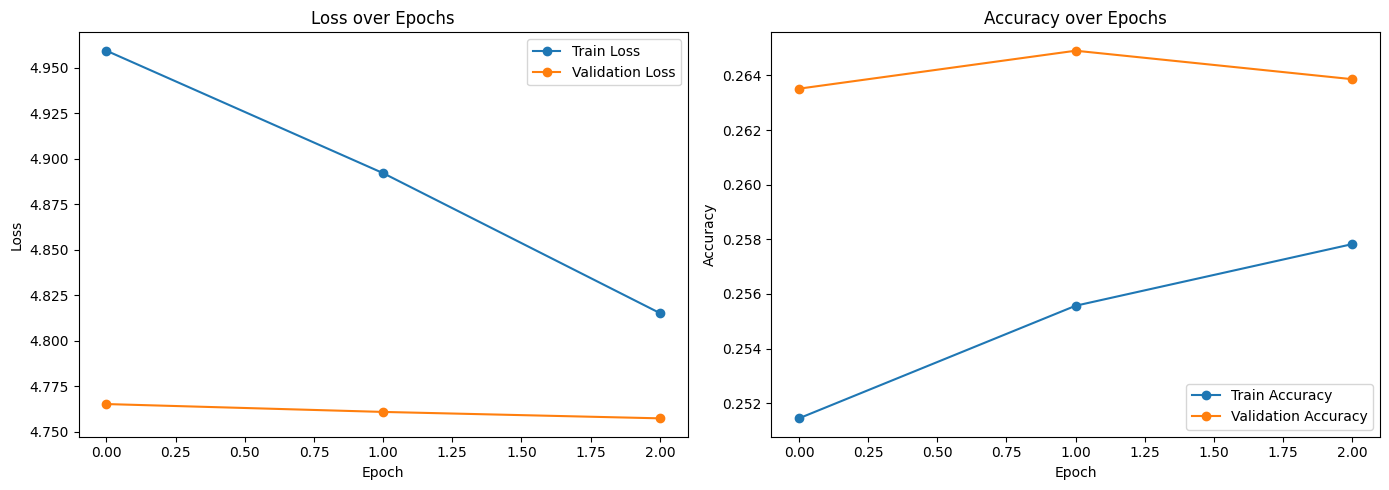

In [40]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
DECODER_LEN = SUMMARY_MAX_LEN - 1

encoder_inputs = Input(shape=(CODE_MAX_LEN,), name='encoder_input')
encoder_embedding = Embedding(input_dim=CODE_VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True, name='encoder_embedding')(encoder_inputs)
encoder_gru = GRU(UNITS, return_state=True, name='encoder_gru')
encoder_outputs, encoder_state = encoder_gru(encoder_embedding)

decoder_inputs = Input(shape=(DECODER_LEN,), name='decoder_input')
decoder_embedding_layer = Embedding(input_dim=SUMMARY_VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True, name='decoder_embedding')
decoder_embedding = decoder_embedding_layer(decoder_inputs)
decoder_gru = GRU(UNITS, return_sequences=True, return_state=True, name='decoder_gru')
decoder_outputs, _ = decoder_gru(decoder_embedding, initial_state=encoder_state)
decoder_dense = Dense(SUMMARY_VOCAB_SIZE, activation='softmax', name='output_layer')
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 100, 128)  │  1,920,000 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_9         │ (None, 100)       │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 19, 128)   │  1,024,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_gru (GRU)   │ [(None, 256),     │    296,448 │ encoder_embeddin… │
│                     │ (None, 256)]      │            │ not_equal_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_gru (GRU)   │ [(None, 19, 256), │    296,448 │ decoder_embeddin… │
│                     │ (None, 256)]      │            │ encoder_gru[0][1] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 19, 8000)  │  2,056,000 │ decoder_gru[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,592,896 (21.34 MB)

 Trainable params: 5,592,896 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
SAMPLE_SIZE = 2000

X_train_tiny = X_train[:SAMPLE_SIZE]
decoder_input_tiny = decoder_input_train[:SAMPLE_SIZE]
decoder_target_tiny = decoder_target_train[:SAMPLE_SIZE]

history = model.fit(
    [X_train_tiny, decoder_input_tiny],
    decoder_target_tiny,
    validation_data=([X_valid[:500], decoder_input_valid[:500]], decoder_target_valid[:500]),
    epochs=3,
    batch_size=256
)

Epoch 1/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 90s 10s/step - accuracy: 0.1254 - loss: 8.9657 - val_accuracy: 0.1740 - val_loss: 8.8760
Epoch 2/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 139s 10s/step - accuracy: 0.1322 - loss: 8.0980 - val_accuracy: 0.0805 - val_loss: 6.2236
Epoch 3/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 80s 10s/step - accuracy: 0.0765 - loss: 6.0807 - val_accuracy: 0.0742 - val_loss: 5.7422


In [43]:
encoder_model = Model(encoder_inputs, encoder_state)

decoder_state_input = Input(shape=(UNITS,))
decoder_embedding_inf = decoder_embedding_layer(decoder_inputs)
decoder_outputs_inf, decoder_state_inf = decoder_gru(decoder_embedding_inf, initial_state=decoder_state_input)
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

decoder_model = Model([decoder_inputs, decoder_state_input], [decoder_outputs_inf, decoder_state_inf])

summary_word_index = summary_tokenizer.word_index
summary_index_word = {v: k for k, v in summary_word_index.items()}

def generate_summary(input_code):
    input_code = add_spaces_around_symbols(clean_code(input_code))
    input_seq = pad_sequences(code_tokenizer.texts_to_sequences([input_code]), maxlen=CODE_MAX_LEN, padding='post', truncating='post')

    state = encoder_model.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, DECODER_LEN))
    target_seq[0, 0] = summary_word_index['startseq']

    result = []
    for i in range(DECODER_LEN - 1):
        output_tokens, state = decoder_model.predict([target_seq, state], verbose=0)
        sampled_token_index = np.argmax(output_tokens[0, i, :])
        sampled_word = summary_index_word.get(sampled_token_index, '')

        if sampled_word == 'endseq' or sampled_word == '':
            break
        result.append(sampled_word)
        target_seq[0, i+1] = sampled_token_index

    return ' '.join(result)

In [44]:
import pickle

model.save('code-summarization-gru/models/gru_summarizer.h5')

with open('code-summarization-gru/models/code_tokenizer.pkl', 'wb') as f:
    pickle.dump(code_tokenizer, f)

with open('code-summarization-gru/models/summary_tokenizer.pkl', 'wb') as f:
    pickle.dump(summary_tokenizer, f)

print("Model aur tokenizers saved ✅")

Model aur tokenizers saved ✅


In [45]:
import numpy as np

In [46]:
import numpy as np

encoder_model = Model(encoder_inputs, encoder_state)

decoder_state_input = Input(shape=(UNITS,))
decoder_embedding_inf = decoder_embedding_layer(decoder_inputs)
decoder_outputs_inf, decoder_state_inf = decoder_gru(decoder_embedding_inf, initial_state=decoder_state_input)
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

decoder_model = Model([decoder_inputs, decoder_state_input], [decoder_outputs_inf, decoder_state_inf])

summary_word_index = summary_tokenizer.word_index
summary_index_word = {v: k for k, v in summary_word_index.items()}

def generate_summary(input_code):
    input_code = add_spaces_around_symbols(clean_code(input_code))
    input_seq = pad_sequences(code_tokenizer.texts_to_sequences([input_code]), maxlen=CODE_MAX_LEN, padding='post', truncating='post')

    state = encoder_model.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, DECODER_LEN))
    target_seq[0, 0] = summary_word_index['startseq']

    result = []
    for i in range(DECODER_LEN - 1):
        output_tokens, state = decoder_model.predict([target_seq, state], verbose=0)
        sampled_token_index = np.argmax(output_tokens[0, i, :])
        sampled_word = summary_index_word.get(sampled_token_index, '')

        if sampled_word == 'endseq' or sampled_word == '':
            break
        result.append(sampled_word)
        target_seq[0, i+1] = sampled_token_index

    return ' '.join(result)